# Sara Batatawala || 221A004 || 4


## 1. Import dependencies


In [ ]:
import os
import gymnasium as gym
import numpy as np

## 2. Load environment


In [ ]:
env = gym.make("Taxi-v3",render_mode="rgb_array")
state = env.reset()
state

(392, {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
env.observation_space.n

np.int64(500)

In [ ]:
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
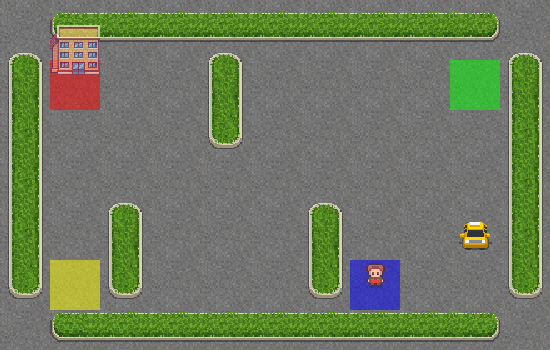

In [ ]:
env.render()

In [ ]:
env.step(4)

(392,
 -10,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

## Possible actions
down(0), up(1), right(2), left (3), pick-up(4) and drop-off(5)

In [ ]:
n_states=env.observation_space.n
n_actions=env.action_space.n

n_actions


np.int64(6)

## How good does behaving completely random do ?

In [ ]:
state=env.reset()
counter=0
g=0
reward=None

In [ ]:
while reward != 20:
    state,reward,done,info=env.step(env.action_space.sample())
    counter+=1
    g+=reward

In [ ]:
print("Solved in {} Steps with a total reward of {}".format(counter,g))

Solved in 495 Steps with a total reward of -1977


## Let's look at just one episode and see how the Q values change after each step using the formula below
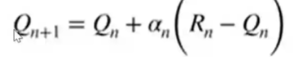

In [ ]:
Q=np.zeros([n_states,n_actions])
print(n_actions)

6


In [ ]:
episodes=1
G=0
alpha=0.618


In [ ]:
for episode in range(1, episodes+1):
  steps_q_learning = 0
  G, reward=0,0
  state, _ = env.reset()
  state = int(state)
  finalState=state
  print(f"Initial state {state}")
  while reward != 20:
      action=np.argmax(Q[state])
      state2_tuple, reward, terminated, truncated, info  = env.step(action)
      state2 = int(state2_tuple)
      Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
      G += reward
      steps_q_learning += 1
      state=state2
  print(f"Episode {episode} solved in {steps_q_learning} steps with a total reward of {G}")

Initial state 332
Episode 1 solved in 14 steps with a total reward of 7


In [ ]:
finalState

332

In [ ]:
G

7

## After 1 episode of implementing Q learnign total reward is better than random approach

## This way we get the optimal policy solution (agent learnt the optimal policy)